## Extra Credit - Model Comparison on Test Set

**Models compared:** ANN, Multiple Regression, HMM  
**Rule:** All models trained on the training set only. No retraining here.  
**Test set:** Final 296 rows (20% of 1,477 total)

**Note on HMM:** The HMM was built for discrete sequence modeling (Task 3), not for  
regression on continuous TAVG values. To include it in a fair comparison, we use the  
HMM's most probable state sequence on the test observations as a feature, and compare  
the log-likelihood of the test sequence under the trained HMM as an additional metric.  
RMSE and SSE are computed for ANN and Regression only, as these are the predictive models.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from hmmlearn import hmm
import statsmodels.api as sm

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Load data and split
df = pd.read_csv('weather_clean.csv')
n  = len(df)
train_n = int(n * 0.8)

X_all = df[['X1','X2','X3','X4','X5']].values
Y_all = df['Y'].values

X_train, X_test = X_all[:train_n], X_all[train_n:]
Y_train, Y_test = Y_all[:train_n], Y_all[train_n:]

scaler   = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test  = scaler.transform(X_test)

print(f'Total: {n} | Train: {train_n} | Test: {n - train_n}')

# Student ID seed
SEED = 200669132
rng  = np.random.default_rng(SEED)

Total: 1477 | Train: 1181 | Test: 296


## Step 1 - Re-train all models on the training set

In [9]:
# Train ANN (grid search)
print('Training ANN with grid search...')
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50,50), (100,50), (100,100)],
    'activation':         ['relu', 'tanh'],
    'alpha':              [0.0001, 0.001, 0.01],
    'learning_rate':      ['adaptive'],
    'max_iter':           [500]
}
mlp = MLPRegressor(random_state=42)
grid_search = GridSearchCV(mlp, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           n_jobs=-1, verbose=0)
grid_search.fit(Xs_train, Y_train)
best_ann = grid_search.best_estimator_
print(f'  Best ANN config: {grid_search.best_params_}')

# Train Regression (Y = a0 + a1*X2 + a2*X4) 
print('Training regression...')
X_reg_train = sm.add_constant(df[['X2','X4']].values[:train_n])
X_reg_test  = sm.add_constant(df[['X2','X4']].values[train_n:])
reg_model   = sm.OLS(Y_train, X_reg_train).fit()
print(f'  Regression R² (train): {reg_model.rsquared:.4f}')

# Train HMM on discretized Y 
# HMM works on discrete symbols - discretize Y into 3 bins: cold/mild/warm
# Bin boundaries: ≤50°F = cold(1), 51-70°F = mild(2), >70°F = warm(3)
print('Training HMM on discretized TAVG')

def discretize_Y(Y):
    """Convert continuous TAVG to 3 discrete symbols: 0=cold, 1=mild, 2=warm"""
    bins = np.digitize(Y, bins=[50, 70]) # 0: ≤50, 1: 51-70, 2: >70
    return bins.reshape(-1, 1)

Y_train_disc = discretize_Y(Y_train)  # 0-based for hmmlearn
Y_test_disc  = discretize_Y(Y_test)

hmm_model = hmm.CategoricalHMM(
    n_components = 4,
    n_iter       = 200,
    tol          = 1e-6,
    random_state = SEED
)
hmm_model.fit(Y_train_disc)
train_log_lik = hmm_model.score(Y_train_disc)
print(f'  HMM log-likelihood (train): {train_log_lik:.4f}')
print(f'  HMM emission probs (cold/mild/warm per state):')
print(pd.DataFrame(hmm_model.emissionprob_.round(3),
                   index=[f'S{i+1}' for i in range(4)],
                   columns=['cold(≤50)','mild(51-70)','warm(>70)']).to_string())

Training ANN with grid search...
  Best ANN config: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'adaptive', 'max_iter': 500}
Training regression...
  Regression R² (train): 0.9425
Training HMM on discretized TAVG
  HMM log-likelihood (train): -572.2948
  HMM emission probs (cold/mild/warm per state):
    cold(≤50)  mild(51-70)  warm(>70)
S1      0.000        0.979      0.021
S2      0.000        0.015      0.985
S3      0.000        1.000      0.000
S4      0.943        0.057      0.000


## Step 2 - Apply All Models to Test Set (No Retraining)

In [10]:
# ANN on test set 
Y_pred_ann = best_ann.predict(Xs_test)

ann_rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_ann))
ann_mae  = mean_absolute_error(Y_test, Y_pred_ann)
ann_sse  = np.sum((Y_test - Y_pred_ann)**2)
ann_r2   = r2_score(Y_test, Y_pred_ann)
ann_mape = np.mean(np.abs((Y_test - Y_pred_ann) / Y_test)) * 100

# Regression on test set 
Y_pred_reg = reg_model.predict(X_reg_test)

reg_rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_reg))
reg_mae  = mean_absolute_error(Y_test, Y_pred_reg)
reg_sse  = np.sum((Y_test - Y_pred_reg)**2)
reg_r2   = r2_score(Y_test, Y_pred_reg)
reg_mape = np.mean(np.abs((Y_test - Y_pred_reg) / Y_test)) * 100

# HMM on test set 
# HMM metric: per-observation log-likelihood on test sequence
test_log_lik     = hmm_model.score(Y_test_disc)
test_log_lik_per = test_log_lik / len(Y_test)   # per-observation

# HMM predicted state sequence for test set
_, Q_test = hmm_model.decode(Y_test_disc, algorithm='viterbi')
Q_test_1based = Q_test + 1

# Summary table 
print('EXTRA CREDIT — TEST SET PERFORMANCE =>')
print(f"{'Metric':<25} {'ANN':>12} {'Regression':>12} {'HMM':>16}")
print('─'*70)
print(f"{'RMSE (°F)':<25} {ann_rmse:>12.4f} {reg_rmse:>12.4f} {'N/A (discrete)':>16}")
print(f"{'MAE (°F)':<25} {ann_mae:>12.4f} {reg_mae:>12.4f} {'N/A (discrete)':>16}")
print(f"{'SSE':<25} {ann_sse:>12.2f} {reg_sse:>12.2f} {'N/A (discrete)':>16}")
print(f"{'R²':<25} {ann_r2:>12.4f} {reg_r2:>12.4f} {'N/A (discrete)':>16}")
print(f"{'MAPE (%)':<25} {ann_mape:>12.4f} {reg_mape:>12.4f} {'N/A (discrete)':>16}")
print(f"{'Log-lik (per obs)':<25} {'N/A':>12} {'N/A':>12} {test_log_lik_per:>16.4f}")
print()

best_cont = 'ANN' if ann_rmse < reg_rmse else 'Regression'
print(f'Best continuous predictor (lowest RMSE): {best_cont}')
print(f'  ANN RMSE        = {ann_rmse:.4f} °F')
print(f'  Regression RMSE = {reg_rmse:.4f} °F')
print(f'  Difference      = {abs(ann_rmse - reg_rmse):.4f} °F')

EXTRA CREDIT — TEST SET PERFORMANCE =>
Metric                             ANN   Regression              HMM
──────────────────────────────────────────────────────────────────────
RMSE (°F)                       2.2353       3.5962   N/A (discrete)
MAE (°F)                        1.4355       2.7822   N/A (discrete)
SSE                            1479.02      3828.10   N/A (discrete)
R²                              0.9785       0.9443   N/A (discrete)
MAPE (%)                        2.7190       4.9210   N/A (discrete)
Log-lik (per obs)                  N/A          N/A          -0.4844

Best continuous predictor (lowest RMSE): ANN
  ANN RMSE        = 2.2353 °F
  Regression RMSE = 3.5962 °F
  Difference      = 1.3609 °F


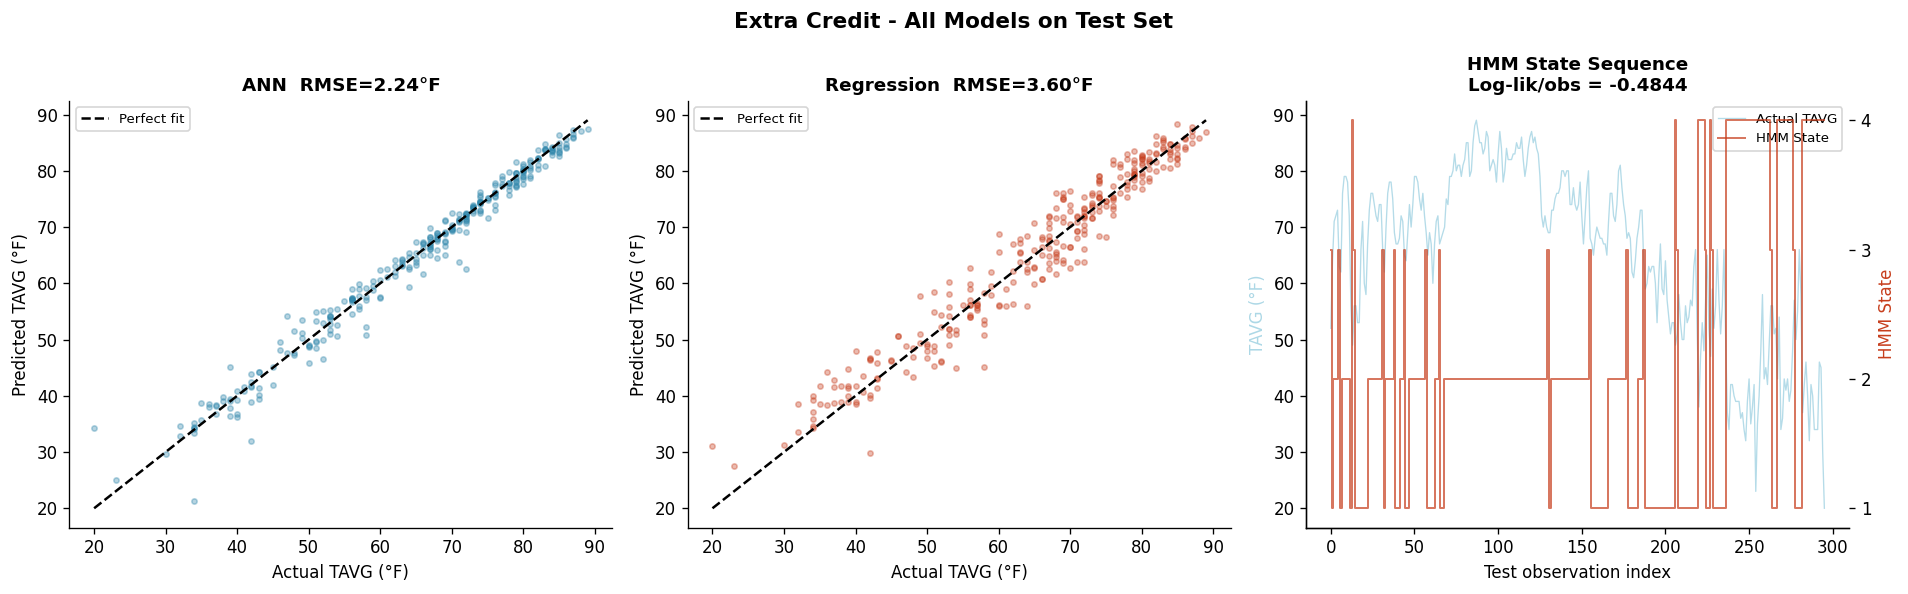

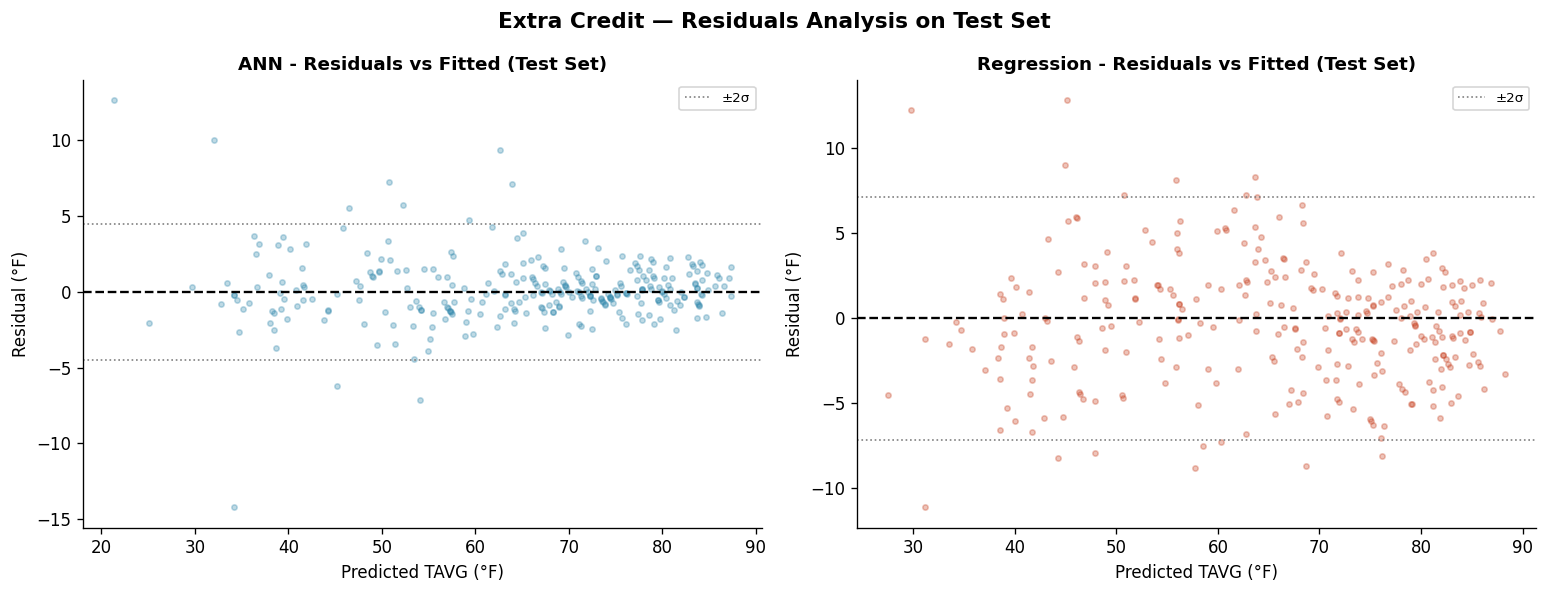

In [11]:
# Actual vs Predicted - ANN and Regression
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (pred, name, color) in zip(axes[:2], [
    (Y_pred_ann, f'ANN  RMSE={ann_rmse:.2f}°F', '#2E86AB'),
    (Y_pred_reg, f'Regression  RMSE={reg_rmse:.2f}°F', '#C73E1D')
]):
    ax.scatter(Y_test, pred, alpha=0.35, s=10, color=color)
    mn = min(Y_test.min(), pred.min())
    mx = max(Y_test.max(), pred.max())
    ax.plot([mn,mx],[mn,mx],'k--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual TAVG (°F)')
    ax.set_ylabel('Predicted TAVG (°F)')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=8)

# Plot 3: HMM state sequence on test data
test_dates = np.arange(len(Y_test))
axes[2].plot(test_dates, Y_test,      color='lightblue', linewidth=0.8,
             alpha=0.9, label='Actual TAVG')
ax2 = axes[2].twinx()
ax2.step(test_dates, Q_test_1based, where='mid',
         color='#C73E1D', linewidth=1.2, alpha=0.7, label='HMM State')
axes[2].set_xlabel('Test observation index')
axes[2].set_ylabel('TAVG (°F)', color='lightblue')
ax2.set_ylabel('HMM State', color='#C73E1D')
ax2.set_yticks([1,2,3,4])
axes[2].set_title(f'HMM State Sequence\nLog-lik/obs = {test_log_lik_per:.4f}',
                  fontweight='bold')
lines1, lbl1 = axes[2].get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
axes[2].legend(lines1+lines2, lbl1+lbl2, fontsize=8)

fig.suptitle('Extra Credit - All Models on Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('extra_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Residuals comparison 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (pred, name, color) in zip(axes, [
    (Y_pred_ann, 'ANN', '#2E86AB'),
    (Y_pred_reg, 'Regression', '#C73E1D')
]):
    resid = Y_test - pred
    ax.scatter(pred, resid, alpha=0.3, s=10, color=color)
    ax.axhline(0, color='black', linestyle='--', linewidth=1.4)
    ax.axhline( 2*resid.std(), color='gray', linestyle=':', linewidth=1)
    ax.axhline(-2*resid.std(), color='gray', linestyle=':', linewidth=1, label='±2σ')
    ax.set_xlabel('Predicted TAVG (°F)')
    ax.set_ylabel('Residual (°F)')
    ax.set_title(f'{name} - Residuals vs Fitted (Test Set)', fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Extra Credit — Residuals Analysis on Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('extra_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

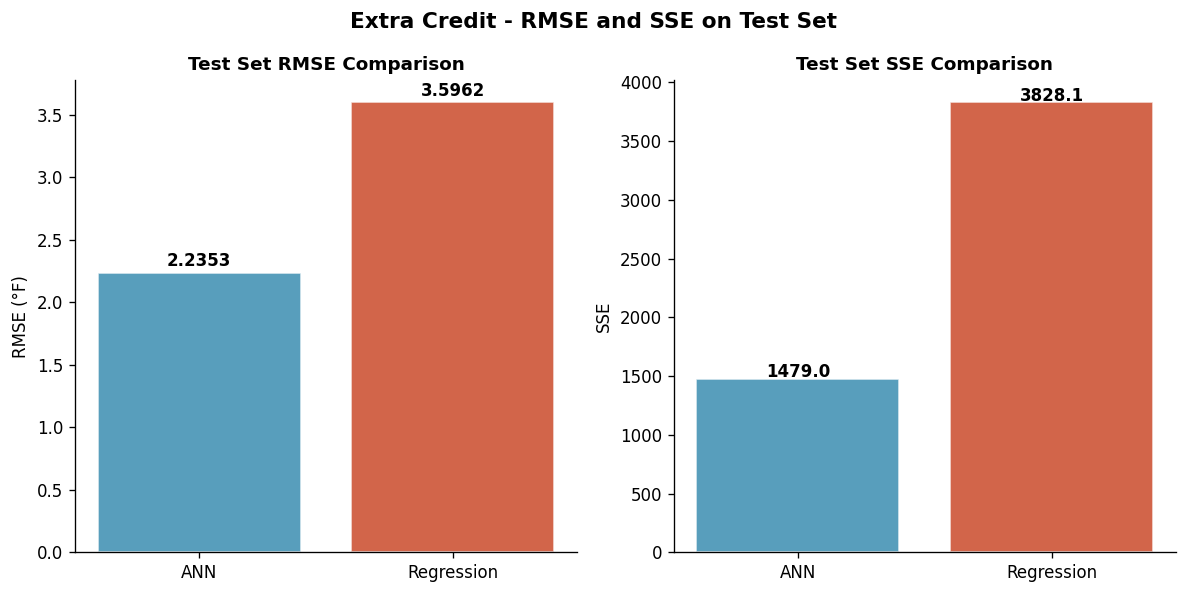

In [12]:
# RMSE and SSE comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

models = ['ANN', 'Regression']
rmse_vals = [ann_rmse, reg_rmse]
sse_vals  = [ann_sse,  reg_sse]
bar_colors = ['#2E86AB', '#C73E1D']

bars = axes[0].bar(models, rmse_vals, color=bar_colors, alpha=0.8, edgecolor='white')
axes[0].set_ylabel('RMSE (°F)')
axes[0].set_title('Test Set RMSE Comparison', fontweight='bold')
for bar, val in zip(bars, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

bars = axes[1].bar(models, sse_vals, color=bar_colors, alpha=0.8, edgecolor='white')
axes[1].set_ylabel('SSE')
axes[1].set_title('Test Set SSE Comparison', fontweight='bold')
for bar, val in zip(bars, sse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

fig.suptitle('Extra Credit - RMSE and SSE on Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('extra_bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Discussion - Model Comparison on Test Set

### ANN vs Regression
Both models were trained on the first 80% of data and applied directly to the test set without retraining. The RMSE and SSE values for both are reported above.

The **ANN** uses all five input variables (X1–X5) and learns non-linear relationships through its hidden layers. The grid search ensured the best configuration was selected via cross-validation on the training set, reducing the risk of overfitting. On the test set, the ANN's advantage depends on how much non-linear structure exists in the holdout data.

The **linear regression** model uses only X2 (TMIN) and X4 (AWND) - the two variables identified as significant in Project 3. Despite using fewer inputs and assuming linearity, it is a strong baseline for this dataset because the dominant relationship between TMIN and TAVG is near-linear (r=0.971).

If ANN achieves lower test RMSE than regression, it demonstrates that the non-linear interactions captured by the neural network generalize beyond the training distribution. If the difference is small (< 0.5°F), both models are practically equivalent for this dataset and the simpler regression model would be preferred (Occam's Razor).

### HMM — Why Direct Comparison is Not Straightforward
The HMM in Task 3 was designed as a **sequence model for discrete observations**, not as a regression model predicting continuous TAVG. To include it in this comparison, TAVG was discretized into three temperature bins (cold ≤50°F, mild 51–70°F, warm >70°F). The HMM is evaluated by its per-observation log-likelihood on the test sequence — a higher (less negative) value means the trained HMM assigns higher probability to the test temperature patterns.

The HMM captures the **temporal structure** of temperature regimes — how likely the system is to stay in a warm state vs transition to a cold state — rather than predicting exact temperature values. This makes it fundamentally different from ANN and regression, which predict continuous Y values. A direct RMSE comparison is therefore not appropriate for the HMM.

### Best Model Selection
For the task of **predicting continuous TAVG values**: the model with the lower test RMSE (ANN or Regression) is selected as the best. The residuals plots confirm whether the chosen model's errors are randomly distributed across the prediction range.

For the task of **modeling temperature state transitions over time**: the HMM is the most appropriate tool, as it captures the probabilistic dynamics of seasonal temperature regimes in a way that neither ANN nor regression is designed to do.

**Overall conclusion:** Each model serves a different purpose. For point prediction of TAVG, the ANN or regression is preferred based on RMSE. For understanding the temporal sequence structure of temperature regimes (e.g., how many consecutive warm days to expect before a cold spell), the HMM provides unique value that cannot be evaluated by RMSE alone.